# Exercise: Tidy data  

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [6]:
os.getcwd()

'/Users/skuhn/git/PythonforBiologists/data'

In [8]:
# dir = os.getcwd()
os.listdir(os.getcwd())

['.DS_Store',
 'BCA.xlsx',
 'Untitled.ipynb',
 'gfmt_sleep.csv',
 'Finches',
 'penguins_subset.csv',
 'Hypoxia',
 '.ipynb_checkpoints',
 'temp_humidity.csv',
 'bsubtilis_stress',
 'Frogs']

In [20]:
penguins_data = os.path.join('/Users/skuhn/git/PythonforBiologists/data', 'penguins_subset.csv')

data = pd.read_csv(penguins_data, header=[0,1])
data.head()

Gentoo                                                     Adelie  \
  bill_depth_mm bill_length_mm flipper_length_mm body_mass_g bill_depth_mm   
0          16.3           48.4             220.0      5400.0          18.5   
1          15.8           46.3             215.0      5050.0          16.9   
2          14.2           47.5             209.0      4600.0          19.5   
3          15.7           48.7             208.0      5350.0          18.3   
4          14.1           48.7             210.0      4450.0          18.0   

                                                   Chinstrap                 \
  bill_length_mm flipper_length_mm body_mass_g bill_depth_mm bill_length_mm   
0           36.8             193.0      3500.0          18.3           47.6   
1           37.0             185.0      3000.0          16.7           42.5   
2           42.0             200.0      4050.0          16.6           40.9   
3           42.7             196.0      4075.0          20.0           52.8   
4           35.7             202.0      3550.0          18.7           45.4   

                                 
  flipper_length_mm body_mass_g  
0             195.0      3850.0  
1             187.0      3350.0  
2             187.0      3200.0  
3             205.0      4550.0  
4             188.0      3525.0

In [25]:
df_tidy = data.stack(
    level=0,
    future_stack=True
).sort_index(
    level=1
).reset_index(
    level=1
).rename(
    columns={"level_1": "species"}
)

df_tidy.head()

,species,bill_depth_mm,bill_length_mm,flipper_length_mm,body_mass_g
0,Adelie,18.5,36.8,193.0,3500.0
1,Adelie,16.9,37.0,185.0,3000.0
2,Adelie,19.5,42.0,200.0,4050.0
3,Adelie,18.3,42.7,196.0,4075.0
4,Adelie,18.0,35.7,202.0,3550.0


In [33]:
species = df_tidy['species'].unique()

In [39]:
# Manual split-apply-"combine"

bill_length_list = []
bill_depth_list = []
flipper_length_list = []
body_mass_list = []

for i in species:
    print(i)
    tmp = df_tidy.loc[df_tidy['species'] == i]
    bill_depth_list.append(tmp['bill_depth_mm'].mean())
    
    

Adelie
Chinstrap
Gentoo


In [42]:
grouped = df_tidy.groupby('species')
grouped['bill_depth_mm'].mean()

species
Adelie       18.135294
Chinstrap    18.420588
Gentoo       15.013235
Name: bill_depth_mm, dtype: float64

In [53]:
columns = df_tidy.columns.to_list()
columns[1:]

['bill_depth_mm', 'bill_length_mm', 'flipper_length_mm', 'body_mass_g']

In [48]:
df_tidy.groupby('species')[['bill_depth_mm', 'bill_length_mm']].agg(['mean', 'std', 'sem'])

bill_depth_mm                     bill_length_mm                    
                   mean       std       sem           mean       std       sem
species                                                                       
Adelie        18.135294  1.116333  0.135375      38.476471  2.820454  0.342030
Chinstrap     18.420588  1.135395  0.137687      48.833824  3.339256  0.404944
Gentoo        15.013235  1.056735  0.128148      47.419118  3.071985  0.372533

In [54]:
df_tidy.groupby('species')[columns[1:]].agg(['mean', 'std', 'sem'])

bill_depth_mm                     bill_length_mm            \
                   mean       std       sem           mean       std   
species                                                                
Adelie        18.135294  1.116333  0.135375      38.476471  2.820454   
Chinstrap     18.420588  1.135395  0.137687      48.833824  3.339256   
Gentoo        15.013235  1.056735  0.128148      47.419118  3.071985   

                    flipper_length_mm                      body_mass_g  \
                sem              mean       std       sem         mean   
species                                                                  
Adelie     0.342030        189.602941  6.633564  0.804438  3621.691176   
Chinstrap  0.404944        195.823529  7.131894  0.864869  3733.088235   
Gentoo     0.372533        216.514706  6.316273  0.765961  5058.455882   

                                  
                  std        sem  
species                           
Adelie     459.597171  55.734344  
Chinstrap  384.335081  46.607475  
Gentoo     522.972458  63.419726

# Exploratory plotting

Adelie
Chinstrap
Gentoo


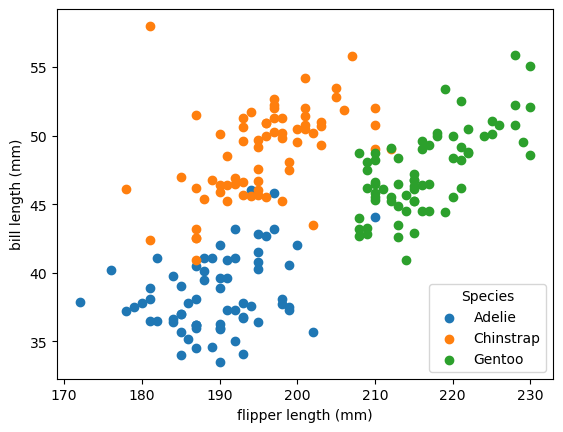

In [59]:
fig, ax = plt.subplots()

for i in species:
    print(i)
    tmp = df_tidy.loc[df_tidy['species'] == i]
    
    x = tmp['flipper_length_mm']
    y = tmp['bill_length_mm']
    
    ax.scatter(x, y,
              label=i)

ax.set_xlabel('flipper length (mm)')
ax.set_ylabel('bill length (mm)')
ax.legend(title='Species')